<a href="https://colab.research.google.com/github/Tolureis/CMPE-460-Deep-Learning/blob/main/Double_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using: cpu
Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Training examples: 4000
Test examples: 4000
Input dimension: 40
=== Starting Double Descent Experiment ===
Training model with 2 hidden units...
Epoch    0: TrainErr=86.33%, TestErr=86.47%
Epoch  100: TrainErr=71.97%, TestErr=69.23%
Epoch  200: TrainErr=70.30%, TestErr=68.10%
Epoch  300: TrainErr=70.30%, TestErr=67.48%
Epoch  400: TrainErr=70.20%, TestErr=68.05%
Epoch  500: TrainErr=70.52%, TestErr=67.50%
Epoch  600: TrainErr=70.27%, TestErr=67.85%
Epoch  700: TrainErr=70.93%, TestErr=67.85%
Epoch  800: TrainErr=69.82%, TestErr=67.88%
Epoch  900: TrainErr=70.05%, TestErr=68.20%
Epoch  999: TrainErr=70.45%, TestErr=67.43%
Training model with 4 hidden units...
Epoch    0: TrainErr=90.40%, TestErr=91.30%
Epoch  100: TrainErr=61.60%, TestErr=58.75%
Epoch  200: TrainErr=62.30%, TestErr=58.32%
Epoch  300: TrainErr=61.32%, TestErr=57.88%
Epoch  400: TrainErr=61.70%, TestErr=57.40%
Epoch  500: TrainErr=61.80%,

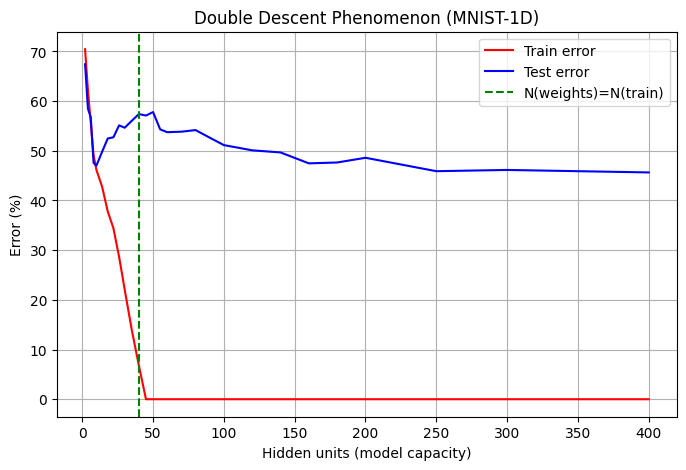

In [ ]:
# -*- coding: utf-8 -*-
"""
8_3_Double_Descent.py
Completed version with English comments and cleaned structure
"""

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import mnist1d
import random

# ==========================================
# 1. DEVICE CONFIGURATION
# ==========================================
random.seed(0)
DEVICE = str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using:', DEVICE)

# ==========================================
# 2. LOAD MNIST-1D DATASET
# ==========================================
args = mnist1d.data.get_dataset_args()
args.num_samples = 8000
args.train_split = 0.5
args.corr_noise_scale = 0.25
args.iid_noise_scale = 2e-2
data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl', download=False, regenerate=True)

# Add 15% random label noise
for c_y in range(len(data['y'])):
    if random.random() < 0.15:
        data['y'][c_y] = int(random.random() * 10)

print(f"Training examples: {len(data['y'])}")
print(f"Test examples: {len(data['y_test'])}")
print(f"Input dimension: {data['x'].shape[-1]}")

# ==========================================
# 3. MODEL AND INITIALIZATION
# ==========================================

def weights_init(layer_in):
    """He initialization for Linear layers"""
    if isinstance(layer_in, nn.Linear):
        nn.init.kaiming_uniform_(layer_in.weight)
        layer_in.bias.data.fill_(0.0)

def get_model(n_hidden):
    """Create an MLP with two hidden layers"""
    D_i = 40   # input dim
    D_k = n_hidden
    D_o = 10   # output classes

    model = nn.Sequential(
        nn.Linear(D_i, D_k),
        nn.ReLU(),
        nn.Linear(D_k, D_k),
        nn.ReLU(),
        nn.Linear(D_k, D_o)
    )
    model.apply(weights_init)
    return model.to(DEVICE)

# ==========================================
# 4. TRAINING FUNCTION
# ==========================================

def fit_model(model, data, n_epoch):
    """Train model and return final training and test error"""
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    x_train = torch.tensor(data['x'].astype('float32')).to(DEVICE)
    y_train = torch.tensor(data['y'].astype('long')).to(DEVICE)
    x_test = torch.tensor(data['x_test'].astype('float32')).to(DEVICE)
    y_test = torch.tensor(data['y_test'].astype('long')).to(DEVICE)

    data_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=100, shuffle=True)

    for epoch in range(n_epoch):
        for x_batch, y_batch in data_loader:
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_function(pred, y_batch)
            loss.backward()
            optimizer.step()

        if epoch % 100 == 0 or epoch == n_epoch-1:
            pred_train = model(x_train)
            pred_test = model(x_test)
            _, pred_train_cls = torch.max(pred_train, 1)
            _, pred_test_cls = torch.max(pred_test, 1)
            train_err = 100 - 100 * (pred_train_cls == y_train).float().mean().item()
            test_err = 100 - 100 * (pred_test_cls == y_test).float().mean().item()
            print(f"Epoch {epoch:4d}: TrainErr={train_err:.2f}%, TestErr={test_err:.2f}%")


    pred_train = model(x_train)
    pred_test = model(x_test)
    _, pred_train_cls = torch.max(pred_train, 1)
    _, pred_test_cls = torch.max(pred_test, 1)
    train_err = 100 - 100 * (pred_train_cls == y_train).float().mean().item()
    test_err = 100 - 100 * (pred_test_cls == y_test).float().mean().item()
    return train_err, test_err

# ==========================================
# 5. COUNT MODEL PARAMETERS
# ==========================================

def count_parameters(model):
    """Count trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ==========================================
# 6. RUN EXPERIMENT (DOUBLE DESCENT)
# ==========================================

hidden_variables = np.array([
    2,4,6,8,10,14,18,22,26,30,35,40,45,50,55,60,
    70,80,90,100,120,140,160,180,200,250,300,400
])

errors_train_all = np.zeros_like(hidden_variables, dtype=float)
errors_test_all = np.zeros_like(hidden_variables, dtype=float)
total_weights_all = np.zeros_like(hidden_variables, dtype=float)

n_epoch = 1000
print("=== Starting Double Descent Experiment ===")


for i, n_hidden in enumerate(hidden_variables):
    print(f"Training model with {n_hidden} hidden units...")
    model = get_model(n_hidden)
    total_weights_all[i] = count_parameters(model)
    errors_train_all[i], errors_test_all[i] = fit_model(model, data, n_epoch)

# ==========================================
# 7. PLOT DOUBLE DESCENT CURVE
# ==========================================

num_training_examples = len(data['y'])
closest_index = np.argmin(np.abs(total_weights_all - num_training_examples))
hidden_at_equal_N = hidden_variables[closest_index]

plt.figure(figsize=(8,5))
plt.plot(hidden_variables, errors_train_all, 'r-', label='Train error')
plt.plot(hidden_variables, errors_test_all, 'b-', label='Test error')
plt.axvline(x=hidden_at_equal_N, color='g', linestyle='--', label='N(weights)=N(train)')
plt.xlabel("Hidden units (model capacity)")
plt.ylabel("Error (%)")
plt.title("Double Descent Phenomenon (MNIST-1D)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
%pip install mnist1d